In [2]:
%pip install -q ipywidgets

Note: you may need to restart the kernel to use updated packages.


In [3]:
from PIL import Image

import ipywidgets as widgets
from IPython.display import display, HTML

import numpy as np
import colorsys

In [4]:
rgb_to_hsv = np.vectorize(colorsys.rgb_to_hsv)
hsv_to_rgb = np.vectorize(colorsys.hsv_to_rgb)

def shift_hue(arr, hout):
    r, g, b, a = np.rollaxis(arr, axis=-1)
    h, s, v = rgb_to_hsv(r, g, b)
    h = hout
    r, g, b = hsv_to_rgb(h, s, v)
    arr = np.dstack((r, g, b, a))
    return arr

def shift_value(arr, vout):
    r, g, b, a = np.rollaxis(arr, axis=-1)
    h, s, v = rgb_to_hsv(r, g, b)
    v = np.clip(v*vout, 0, 255)
    r, g, b = hsv_to_rgb(h, s, v)
    arr = np.dstack((r, g, b, a))
    return arr

def shift_saturation(arr, sout):
    r, g, b, a = np.rollaxis(arr, axis=-1)
    h, s, v = rgb_to_hsv(r, g, b)
    s = np.clip(s*sout, 0, 1.0)
    r, g, b = hsv_to_rgb(h, s, v)
    arr = np.dstack((r, g, b, a))
    return arr


def colorize(image, hue=None, value=None, saturation=None):
    """
    Colorize PIL image `original` with the given
    `hue` (hue within 0-360); returns another PIL image.
    """
    img = image.convert('RGBA')
    arr = np.array(np.asarray(img).astype('float'))
    
    if hue is not None:
        arr = shift_hue(arr, hue/360.)
        
    if value is not None:
        arr = shift_value(arr, value)
        
    if saturation is not None:
        arr = shift_saturation(arr, saturation)
    
    new_img = Image.fromarray(arr.astype('uint8'), 'RGBA')

    return new_img

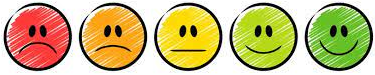

In [5]:
face_strip = Image.open('data/images/faces.png')
face_strip

In [6]:
faces = [ face_strip.crop( (i*75, 0, (i+1)*75, 75) ) for i in range(5) ]

In [7]:
happiness_spectrum = [ 'big frown', 'frown', 'neutral', 'smile', 'big smile' ]

@widgets.interact(
    happiness=happiness_spectrum,
    hue_rotation=(0, 360, 1))
def change_hue(hue_rotation: float, happiness):
    happiness_index = happiness_spectrum.index(happiness)
    face = faces[ happiness_index ]
    return colorize(face, hue_rotation)

interactive(children=(IntSlider(value=180, description='hue_rotation', max=360), Dropdown(description='happine…

In [8]:
from IPython.display import HTML
import base64
from io import BytesIO

def image_to_base64(img):
    """Convert PIL Image to base64 string"""
    buffer = BytesIO()
    img.save(buffer, format='PNG')
    img_str = base64.b64encode(buffer.getvalue()).decode()
    return f"data:image/png;base64,{img_str}"

def display_faces():
    # Convert images to base64
    happy_b64 = image_to_base64(happy)
    neutral_b64 = image_to_base64(neutral)
    sad_mild_b64 = image_to_base64(sad_mild)
    angry_mild_b64 = image_to_base64(angry_mild)
    sad_severe_b64 = image_to_base64(sad_severe)
    angry_severe_b64 = image_to_base64(angry_severe)

    # Create HTML layout
    html = f"""
    <div style="max-width: 340px; margin: 1em; padding: 1em;background-color: white; color: #333; font-family: sans-serif;">
        <style>
            .face-grid {{
                display: grid;
                grid-template-columns: 64px repeat(2, 92px);
                column-gap: 22px;
                row-gap: 18px;
                align-items: center;
                justify-content: center;
            }}
            .row-label {{
                text-align: right;
                font-size: 12px;
            }}
            .face-cell {{
                display: flex;
                justify-content: center;
                align-items: center;
            }}
            .face-cell img {{
                display: block;
                max-width: 92px;
                height: auto;
            }}
            .center-face {{
                grid-column: 2 / 4;
            }}
            .column-label {{
                text-align: center;
                font-size: 12px;
            }}
        </style>
        <div class="face-grid">
            <span class="row-label">happy</span>
            <div class="face-cell center-face"><img src="{happy_b64}"/></div>

            <span class="row-label">neutral</span>
            <div class="face-cell center-face"><img src="{neutral_b64}"/></div>

            <span class="row-label">mild</span>
            <div class="face-cell"><img src="{sad_mild_b64}"/></div>
            <div class="face-cell"><img src="{angry_mild_b64}"/></div>

            <span class="row-label">severe</span>
            <div class="face-cell"><img src="{sad_severe_b64}"/></div>
            <div class="face-cell"><img src="{angry_severe_b64}"/></div>

            <div></div>
            <span class="column-label">sad</span>
            <span class="column-label">angry</span>
        </div>
    </div>
    """

    display(HTML(html))


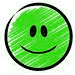
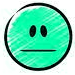
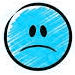
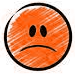
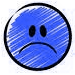
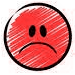

In [9]:
# setup
happy  = colorize(faces[3], 110)
neutral = colorize(faces[2], 160)
sad_mild = colorize(faces[1], 191)
angry_mild = colorize(faces[1], 20)
angry_severe = colorize(faces[0], 0)
sad_severe = colorize(faces[0], 229)

display_faces()